In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [3]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
for columna in df.select_dtypes(include=['string']).columns:
        df[columna] = df[columna].astype('object')

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
#X = df.drop('Churn', axis=1)
#y = df['Churn']
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.select_dtypes(include=['object']).columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [10]:
pipeline_numeric = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5, weights="uniform")),
    ('scaler', StandardScaler())
])
pipeline_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
pipeline_preprocessor = ColumnTransformer([
    ("numeric", pipeline_numeric, df.select_dtypes(include=['int64', 'float64']).columns),
    ("categorical", pipeline_categorical, df.select_dtypes(include=['object']).columns.drop(['Churn', 'customerID']))
])

In [11]:
X_crudo = df.drop(['Churn', 'customerID'], axis=1) 
matriz_limpia = pipeline_preprocessor.fit_transform(X_crudo)

if hasattr(matriz_limpia, "toarray"):
    matriz_limpia = matriz_limpia.toarray()

df_limpia = pd.DataFrame(
    matriz_limpia,
    columns=pipeline_preprocessor.get_feature_names_out()
)
df_limpia['Churn'] = df['Churn'].values
df_limpia.head()

,numeric__SeniorCitizen,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__gender_Female,categorical__gender_Male,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,categorical__Dependents_Yes,...,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,Churn
0,-0.439916,-1.277445,-1.160323,-0.992670,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,No
1,-0.439916,0.066327,-0.259629,-0.172200,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,No
2,-0.439916,-1.236724,-0.362660,-0.958124,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Yes
3,-0.439916,0.514251,-0.746535,-0.193708,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,No
4,-0.439916,-1.236724,0.197365,-0.938932,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,Yes


In [12]:
df_limpia.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   numeric__SeniorCitizen                                7043 non-null   float64
 1   numeric__tenure                                       7043 non-null   float64
 2   numeric__MonthlyCharges                               7043 non-null   float64
 3   numeric__TotalCharges                                 7043 non-null   float64
 4   categorical__gender_Female                            7043 non-null   float64
 5   categorical__gender_Male                              7043 non-null   float64
 6   categorical__Partner_No                               7043 non-null   float64
 7   categorical__Partner_Yes                              7043 non-null   float64
 8   categorical__Dependents_No                            7043 non-null  

# Evaluación de sesgos, ética y privacidad de los datos.

In [34]:
variables_protegidas = [
    'gender', 
    'SeniorCitizen', 
    'Partner', 
    'Dependents'
]

<Axes: xlabel='gender'>

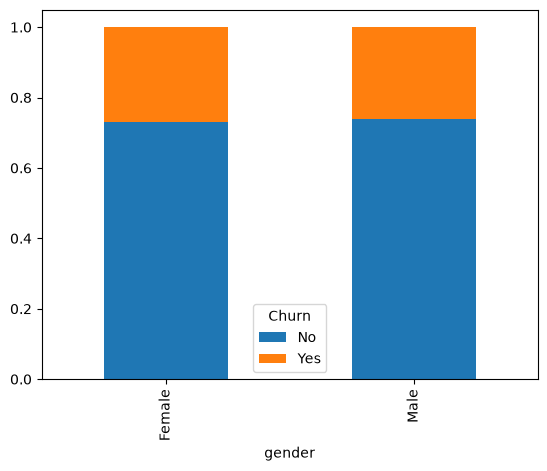

In [15]:
df.groupby("gender")["Churn"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True)

- No se observa una diferencia importante en la tasa real de abanodo entre hombres y mujeres. Por tanto, no hay evidencia inicial de un desequilibrio asociado al genero en los datos analizados.

<Axes: xlabel='SeniorCitizen'>

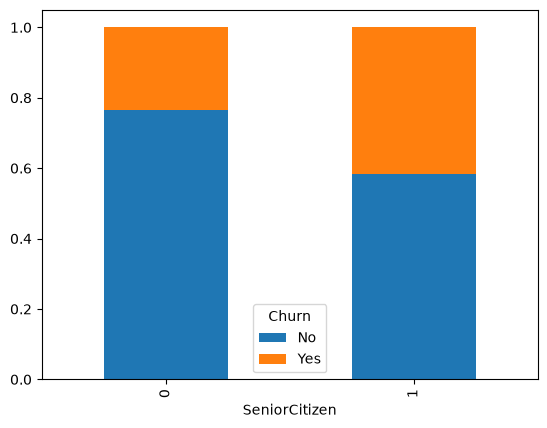

In [16]:
df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True)

- Los clientes mayores tienen una tasa de abandono superior. Esto señala una diferencia que debe investigarse, pero no demuestra por si sola discriminación

<Axes: xlabel='Partner'>

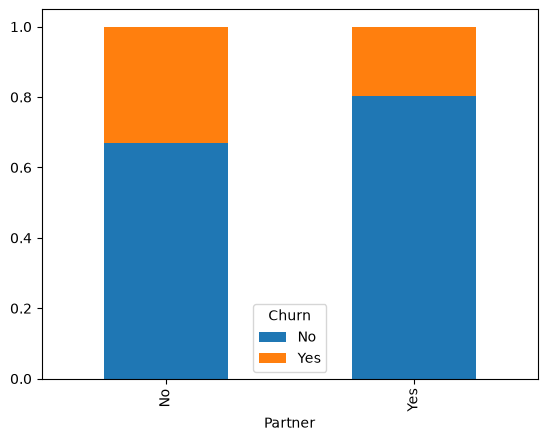

In [19]:
df.groupby("Partner")["Churn"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True)

- Los clientes sin pareja tienen una mayor tasa de abandono del servicio a comparación de lo que estan casados. Sin embargo no demuestran discriminación.

<Axes: xlabel='Dependents'>

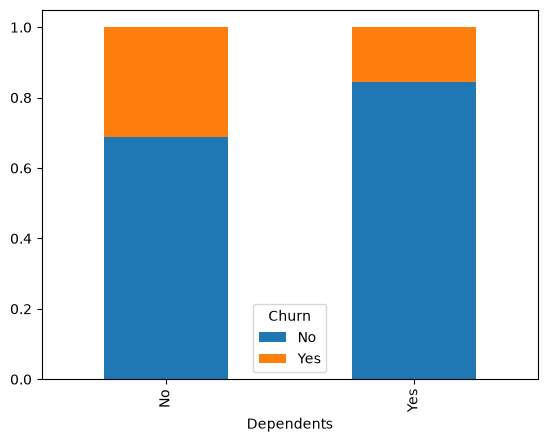

In [20]:
df.groupby("Dependents")["Churn"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True)

- Aquellos clientes que no poseen personas a su cargo economicamente como hijos o familiares mayores tienen una mayor tasa de abandono.

In [35]:
for variable in variables_protegidas:
    print(f"\nVariable: {variable}")
    print(df.groupby(variable)["Churn"].value_counts(normalize=True))


Variable: gender
gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
        Yes      0.261603
Name: proportion, dtype: float64

Variable: SeniorCitizen
SeniorCitizen  Churn
0              No       0.763938
               Yes      0.236062
1              No       0.583187
               Yes      0.416813
Name: proportion, dtype: float64

Variable: Partner
Partner  Churn
No       No       0.670420
         Yes      0.329580
Yes      No       0.803351
         Yes      0.196649
Name: proportion, dtype: float64

Variable: Dependents
Dependents  Churn
No          No       0.687209
            Yes      0.312791
Yes         No       0.845498
            Yes      0.154502
Name: proportion, dtype: float64
